In [11]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Gio
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [12]:
os.chdir(Share_point)

In [13]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

In [14]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [15]:
df = pd.read_csv(r'UA/UA Physical_flow 03_08_2023.csv', encoding='latin1', skiprows=1)

In [16]:
df['Äàòà / Date'] = pd.to_datetime(df['Äàòà / Date'], format='%d.%m.%Y', dayfirst=True)
df['Äàòà / Date'] = df['Äàòà / Date'].sort_values(ascending=True)

In [17]:
df_e = df[df['[EN] Direction']=='Entry']

In [18]:
df_e['[En] Country'].unique()

array(['Moldova', 'Poland', 'Russia', 'Romania', 'Slovakia', 'Hungary'],
      dtype=object)

In [19]:
plt_c = ['Poland', 'Russia', 'Romania', 'Hungary', 'Moldova', 'Slovakia']

In [20]:
df_e = df_e.set_index(pd.DatetimeIndex(df_e['Äàòà / Date']))

In [16]:
df_e[df_e['[En] Country']=='Russia'].groupby(pd.Grouper(freq='W'))

In [17]:
df_e['M3m']= df_e['Èòîã']/1000000

In [18]:
df_e.head(2)

,[UA] Êðà¿íà,[En] Country,[UA] Ãðóïà,[En] Group,[UA] Íàçâà â³ðò. òî÷êè,[En] Virtual IP name,[UA] Íàïðÿì,[EN] Direction,Äàòà / Date,Èòîã,M3m
Äàòà / Date,,,,,,,,,,,
2022-12-01,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âõ³ä,Entry,2022-12-01,2618398.0,2.618398
2022-12-02,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âõ³ä,Entry,2022-12-02,186622.0,0.186622


C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22436\3350567113.py:3: FutureWarning: Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is deprecated and will raise a KeyError in a future Version.
  pol = df_e[df_e['[En] Country']=='Poland']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22436\3350567113.py:5: FutureWarning: Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is deprecated and will raise a KeyError in a future Version.
  hun = df_e[df_e['[En] Country']=='Hungary']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)


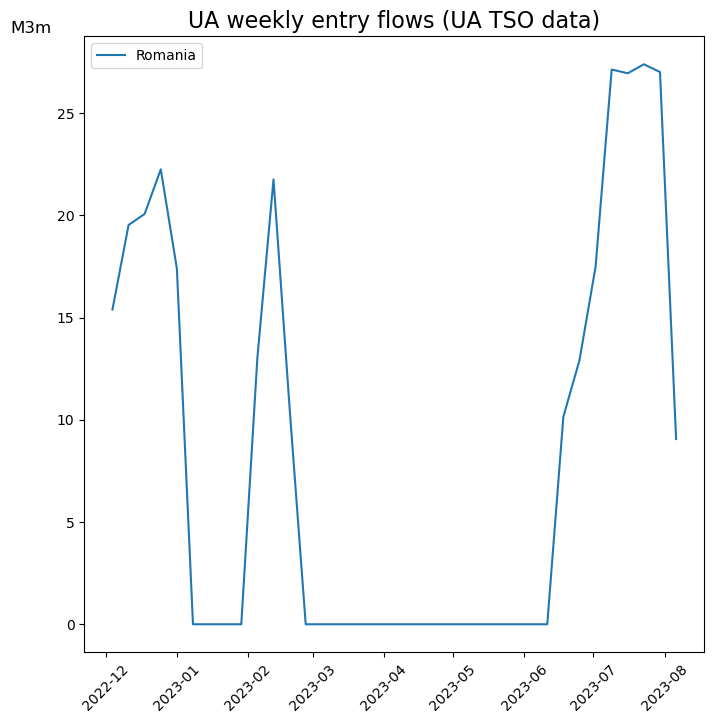

In [23]:
rus = df_e[df_e['[En] Country']=='Russia']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
slov = df_e[df_e['[En] Country']=='Slovakia']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
pol = df_e[df_e['[En] Country']=='Poland']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
rom = df_e[df_e['[En] Country']=='Romania']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
hun = df_e[df_e['[En] Country']=='Hungary']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
mold = df_e[df_e['[En] Country']=='Moldova']['2020':]['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(rus,color='red',label='Russia',linestyle=':')
# ax.plot(slov,label='Slovakia',marker='o')
# ax.plot(pol,label='Poland')
ax.plot(rom,label='Romania')
# ax.plot(hun,label='Hungary')
# ax.plot(mold,label='Moldova')

date_form1 = DateFormatter("%Y-%m")
ax.xaxis.set_major_formatter(date_form1)


plt.xticks(rotation=45)
plt.title('UA weekly entry flows (UA TSO data)',fontsize='16')
plt.ylabel('M3m',fontsize=12,rotation=0,loc='top')
plt.legend(loc='best')

In [17]:
df[(df['[En] Country']=='Slovakia')&(df['Äàòà / Date']>'2023-01-01')&(df['[EN] Direction']=='Entry')]

,[UA] Êðà¿íà,[En] Country,[UA] Ãðóïà,[En] Group,[UA] Íàçâà â³ðò. òî÷êè,[En] Virtual IP name,[UA] Íàïðÿì,[EN] Direction,Äàòà / Date,Èòîã
1366,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-31,3388504.0
1385,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-01-31,7235491.0
1512,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-30,3359561.0
1531,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-01-30,7808047.0
1662,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-29,3423278.0
...,...,...,...,...,...,...,...,...,...,...
11953,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-02,3617739.0
11972,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-02-02,4632510.0
11992,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-01-02,5856165.0
12124,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-01,3355781.0


In [15]:
today = date.today()

d1 = '2023-01-01'
# d2 = '2022-12-31'
d2 = today.strftime("%Y-%m-%d")


converter = 10300000   ## KWh to M3m --> 10.3 KWh/m^3
converterTJ = 277778
kwhtwh = 0.000000001

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe7 in position 2: invalid continuation byte